In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
from utils import DATA_DIR, RANDOM_STATE
from utils.data import CATEGORICAL_COLS

pd.set_option("display.max_columns", 50)
sns.set_style("whitegrid")

DATA_PATH = DATA_DIR / "hour.csv"
OUT_DIR = DATA_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=["dteday"])
print("Shape:", df.shape)
df.head()

Shape: (17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[us]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-null  int64

In [4]:
df.describe(include="all").T

,count,mean,min,25%,50%,75%,max,std
instant,17379.0,8690.0,1.0,4345.5,8690.0,13034.5,17379.0,5017.0295
dteday,17379,2012-01-02 04:08:34.552045,2011-01-01 00:00:00,2011-07-04 00:00:00,2012-01-02 00:00:00,2012-07-02 00:00:00,2012-12-31 00:00:00,NaN
season,17379.0,2.50164,1.0,2.0,3.0,3.0,4.0,1.106918
yr,17379.0,0.502561,0.0,0.0,1.0,1.0,1.0,0.500008
mnth,17379.0,6.537775,1.0,4.0,7.0,10.0,12.0,3.438776
hr,17379.0,11.546752,0.0,6.0,12.0,18.0,23.0,6.914405
holiday,17379.0,0.02877,0.0,0.0,0.0,0.0,1.0,0.167165
weekday,17379.0,3.003683,0.0,1.0,3.0,5.0,6.0,2.005771
workingday,17379.0,0.682721,0.0,0.0,1.0,1.0,1.0,0.465431
weathersit,17379.0,1.425283,1.0,1.0,1.0,2.0,4.0,0.639357


In [5]:
print("Missings per coloumn:")
print(df.isna().sum())
print("\nAnzahl Duplikate:", df.duplicated().sum())

Missings per coloumn:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Anzahl Duplikate: 0


In [6]:
expected_hours = pd.date_range(
    start=df["dteday"].min(),
    end=df["dteday"].max() + pd.Timedelta(hours=23),
    freq="h",
)
print("Erwartete Stunden:", len(expected_hours))
print("Vorhandene Zeilen:", len(df))
print("Fehlende Stunden:", len(expected_hours) - len(df))

Erwartete Stunden: 17544
Vorhandene Zeilen: 17379
Fehlende Stunden: 165


In [7]:
leakage_cols = ["casual", "registered"]
id_cols = ["instant"]

df = df.drop(columns=leakage_cols + id_cols)
df.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


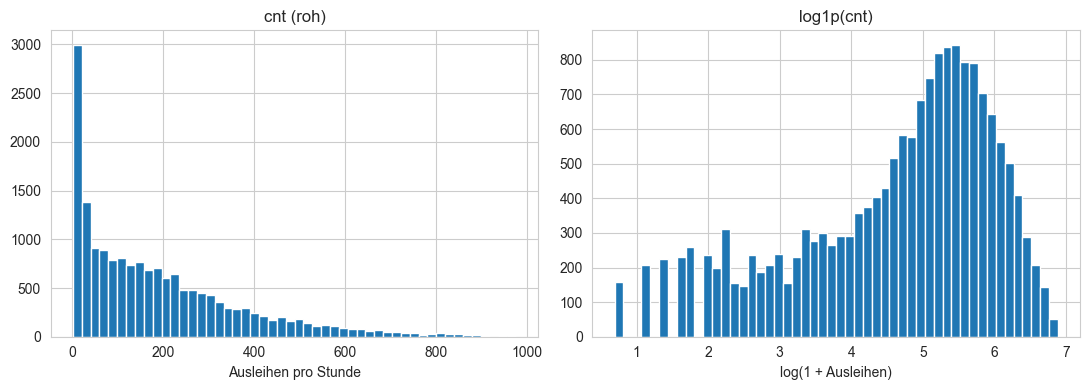

Skewness cnt        : 1.277
Skewness log1p(cnt) : -0.818


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["cnt"], bins=50)
axes[0].set_title("cnt (roh)")
axes[0].set_xlabel("Ausleihen pro Stunde")
axes[1].hist(np.log1p(df["cnt"]), bins=50)
axes[1].set_title("log1p(cnt)")
axes[1].set_xlabel("log(1 + Ausleihen)")
plt.tight_layout()
plt.show()

print("Skewness cnt        :", df["cnt"].skew().round(3))
print("Skewness log1p(cnt) :", np.log1p(df["cnt"]).skew().round(3))

In [9]:
df["cnt_log1p"] = np.log1p(df["cnt"])

In [10]:
# Redundante Features entfernen:
# - workingday ist vollständig aus weekday + holiday ableitbar
# - season ist vollständig aus mnth ableitbar (Monate 3-5 = Frühling usw.)
df = df.drop(columns=["workingday", "season"])

# yr und holiday sind binär (0/1) und werden als float64 behandelt.
# Für Baummodelle ist das äquivalent zu category — kein Informationsverlust.

# Echte kategoriale Features (nominale / ordinale Gruppen) — aus utils.data
numeric_cols = ["temp", "atemp", "hum", "windspeed"]  # atemp folgt später

for col in CATEGORICAL_COLS:
    df[col] = df[col].astype("category")

print(f"Entfernte Features: workingday, season")
print(f"Verbleibende kategoriale Features: {CATEGORICAL_COLS}")
df.dtypes

Entfernte Features: workingday, season
Verbleibende kategoriale Features: ['mnth', 'hr', 'weekday', 'weathersit']


dteday        datetime64[us]
yr                     int64
mnth                category
hr                  category
holiday                int64
weekday             category
weathersit          category
temp                 float64
atemp                float64
hum                  float64
windspeed            float64
cnt                    int64
cnt_log1p            float64
dtype: object

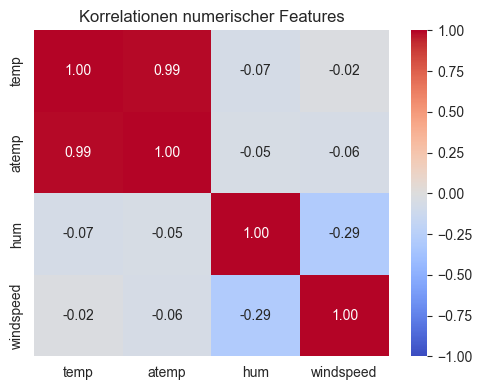

In [11]:
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Korrelationen numerischer Features")
plt.tight_layout()
plt.show()

In [12]:
df = df.drop(columns=["atemp"])
numeric_cols = [c for c in numeric_cols if c != "atemp"]
df.head()

,dteday,yr,mnth,hr,holiday,weekday,weathersit,temp,hum,windspeed,cnt,cnt_log1p
0,2011-01-01,0,1,0,0,6,1,0.24,0.81,0.0,16,2.833213
1,2011-01-01,0,1,1,0,6,1,0.22,0.80,0.0,40,3.713572
2,2011-01-01,0,1,2,0,6,1,0.22,0.80,0.0,32,3.496508
3,2011-01-01,0,1,3,0,6,1,0.24,0.75,0.0,13,2.639057
4,2011-01-01,0,1,4,0,6,1,0.24,0.75,0.0,1,0.693147


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

# Day-Level-Split: alle Stunden eines Tages landen entweder in Train ODER Test,
# nie in beiden. Verhindert temporale Leakage durch benachbarte Stunden desselben
# Tages in unterschiedlichen Splits.
unique_days = df["dteday"].unique()  # ~730 einzigartige Tage

train_days, test_days = train_test_split(
    unique_days,
    test_size=0.30,
    random_state=42,
    shuffle=True,
)

train_df = df[df["dteday"].isin(train_days)].reset_index(drop=True)
test_df  = df[df["dteday"].isin(test_days)].reset_index(drop=True)

print(f"Unique Tage gesamt : {len(unique_days)}")
print(f"Unique Tage Train  : {len(train_days)}")
print(f"Unique Tage Test   : {len(test_days)}")
print(f"Train: {len(train_df)} Zeilen ({len(train_df)/len(df):.1%})")
print(f"Test : {len(test_df)} Zeilen ({len(test_df)/len(df):.1%})")

In [14]:
feature_cols = [c for c in df.columns if c not in ["dteday", "cnt", "cnt_log1p"]]

X_train = train_df[feature_cols]
y_train = train_df["cnt"]
y_train_log = train_df["cnt_log1p"]

X_test = test_df[feature_cols]
y_test = test_df["cnt"]
y_test_log = test_df["cnt_log1p"]

print("Features:", feature_cols)
print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)

Features: ['yr', 'mnth', 'hr', 'holiday', 'weekday', 'weathersit', 'temp', 'hum', 'windspeed']
X_train shape: (12165, 9)
X_test  shape: (5214, 9)


In [15]:
train_df.to_csv(OUT_DIR / "train.csv", index=False)
test_df.to_csv(OUT_DIR / "test.csv", index=False)

print("Gespeichert nach:", OUT_DIR.resolve())

Gespeichert nach: /Users/anton/Desktop/SoSe26/Belegarbeit/Implementation_XAI_Stahl_SoSe26/data
